In [ ]:
import torch 
import torch.nn as nn 
import torch.nn.functional as F 
import torch.optim as optim 
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

import torch_geometric
from torch_geometric.nn import GAT, GraphConv, SAGEConv, SAGPooling, GraphNorm, global_mean_pool, GINEConv
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

import os 
import cv2 
import h5py
import numpy as np 
import matplotlib.pyplot as plt
import networkx as nx
import random
from tqdm import tqdm
from sklearn.neighbors import KDTree
from tqdm import tqdm
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

In [2]:
PATH = "Dataset.hdf5"

In [3]:
files = h5py.File(PATH, "r")
xdataset = np.array(files["X_jets"])
m0  = np.array(files["m0"])
pt = np.array(files["pt"])
ydataset = np.array(files["y"])

In [ ]:
c = random.randint(0, 100000)

np.array(files["m0"])[c], np.array(files["pt"])[c]

(np.float32(22.865505), np.float32(128.53079))

In [5]:
def standard_scale(data):
    
    # Min-Max Scaling to [0, 1]
    min_val = np.min(data)
    max_val = np.max(data)
    scaled_data = (data - min_val) / (max_val - min_val)
    
    return scaled_data

In [6]:
xdataset[:, :, :, 0] = standard_scale(np.sqrt(np.sqrt(xdataset[:, :, :, 0])))
xdataset[:, :, :, 1] = standard_scale(xdataset[:, :, :, 1])
xdataset[:, :, :, 2] = standard_scale(xdataset[:, :, :, 2])


m0 = standard_scale(m0)
pt = standard_scale(pt)

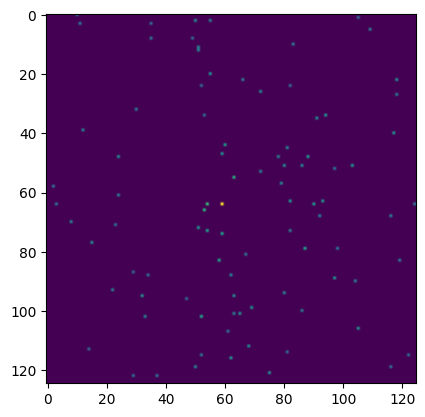

In [7]:
plt.imshow(xdataset[0, :, :, 0])

In [ ]:


def extract_points_from_image(image, label, m0, pt):
    threshold = max(0.01, np.mean(image[image > 0]) * 0.1)
    points = np.argwhere(image > threshold)
    intensities = image[points[:, 0], points[:, 1]]
    z_coords = intensities  # Z from intensity
    return np.column_stack((points, z_coords, np.full(len(points), label), 
                            np.full(len(points), m0), np.full(len(points), pt))) if len(points) > 0 else np.empty((0, 6))

def enrich_features_with_density_and_track(xy_coords, track_img):
    spatial_tree = KDTree(xy_coords)
    neighbors = spatial_tree.query_radius(xy_coords, r=3.0)
    densities = np.array([len(n) for n in neighbors])

    track_points = np.argwhere(track_img > 0)
    if len(track_points) == 0:
        track_distances = np.full(len(xy_coords), 50.0)
    else:
        track_tree = KDTree(track_points)
        track_distances, _ = track_tree.query(xy_coords, k=1)

    return densities, track_distances

def point_cloud_to_graph_3d_radius(ecal_points, hcal_points, track_img):
    if len(ecal_points) == 0 and len(hcal_points) == 0:
        return nx.Graph(), np.empty((0, 6)), np.empty((0, 3))

    all_nodes = np.vstack([ecal_points, hcal_points]) if ecal_points.size and hcal_points.size else ecal_points if ecal_points.size else hcal_points
    all_nodes[:, 2] /= np.max(all_nodes[:, 2]) if np.max(all_nodes[:, 2]) > 0 else 1

    densities, track_dists = enrich_features_with_density_and_track(all_nodes[:, [0, 1]], track_img)
    avg_track_intensity = np.mean(track_img[track_img > 0]) if np.any(track_img > 0) else 0.1
    radius_3d = avg_track_intensity * 100.0

    G = nx.Graph()
    for i, p in enumerate(all_nodes):
        G.add_node(i, intensity=p[2], x=(p[0]/62.5) - 1, y=(p[1]/62.5) - 1, z=p[2],
                   is_ecal=(p[3] == -1), is_hcal=(p[3] == 1),
                   m0=p[4], pt=p[5],
                   density=densities[i], track_dist=track_dists[i])

    kdtree = KDTree(all_nodes[:, :3])
    indices = kdtree.query_radius(all_nodes[:, :3], r=radius_3d)
    for i, neighbors in enumerate(indices):
        for j in neighbors:
            if i != j:
                dist = np.linalg.norm(all_nodes[i, :3] - all_nodes[j, :3])
                weight = np.exp(-dist / 5)
                G.add_edge(i, j, weight=weight)

    # Restore track-to-node edge logic
    track_points = np.argwhere(track_img > 0)
    if len(track_points) > 0:
        track_tree = KDTree(track_points)
        distances, indices = track_tree.query(all_nodes[:, :2], k=1)
        threshold = 5.0  # Set connection distance threshold
        for node_id, (dist, t_idx) in enumerate(zip(distances, indices)):
            if dist[0] < threshold:
                track_node_id = len(all_nodes) + t_idx[0]
                if not G.has_node(track_node_id):
                    G.add_node(track_node_id, intensity=0, 
                               x=(track_points[t_idx[0]][0]/62.5)-1, 
                               y=(track_points[t_idx[0]][1]/62.5)-1, z=0.05,
                               is_ecal=False, is_hcal=False,
                               m0=0, pt=0, density=0, track_dist=0)
                G.add_edge(node_id, track_node_id, weight=np.exp(-dist[0]/5))

    return G, all_nodes, track_points

def convert_to_pyg_graph(graph):
    if len(graph) == 0:
        return None

    node_features = [[attrs['intensity'], attrs['x'], attrs['y'], attrs['z'],
                      attrs['is_ecal'], attrs['is_hcal'], attrs['m0'], 
                      attrs['pt'], attrs['density'], attrs['track_dist']] 
                     for _, attrs in graph.nodes(data=True)]

    node_mapping = {node: i for i, node in enumerate(graph.nodes())}
    edge_index = torch.tensor([[node_mapping[u], node_mapping[v]] for u, v in graph.edges()], dtype=torch.long).t().contiguous()
    edge_weights = torch.tensor([graph[u][v]['weight'] for u, v in graph.edges()], dtype=torch.float)

    return Data(x=torch.tensor(node_features, dtype=torch.float), edge_index=edge_index, edge_attr=edge_weights)

def plot_point_cloud(all_nodes, track_points):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    ecal_mask = all_nodes[:, 3] == -1
    hcal_mask = all_nodes[:, 3] == 1

    ax.scatter(all_nodes[ecal_mask][:, 0], all_nodes[ecal_mask][:, 1], all_nodes[ecal_mask][:, 2],
               c='green', label='ECAL', alpha=0.6, s=10)
    ax.scatter(all_nodes[hcal_mask][:, 0], all_nodes[hcal_mask][:, 1], all_nodes[hcal_mask][:, 2],
               c='red', label='HCAL', alpha=0.6, s=10)
    if len(track_points) > 0:
        z_const = np.full(len(track_points), 0.05)
        ax.scatter(track_points[:, 0], track_points[:, 1], z_const,
                   c='blue', label='Track', alpha=0.4, s=8)

    ax.set_xlabel('X (pixel)')
    ax.set_ylabel('Y (pixel)')
    ax.set_zlabel('Z (Intensity)')
    ax.set_title('3D Point Cloud with ECAL, HCAL, and Track Points')
    ax.legend()
    plt.tight_layout()
    plt.show()

def process_dataset(xdataset, ydataset, m0_values, pt_values, visualize=True):
    graph_dataset = []
    for idx, (xdata, ydata) in enumerate(tqdm(zip(xdataset, ydataset), desc="Processing Enhanced 3D Graphs")):
        ecal_points = extract_points_from_image(xdata[:, :, 0], -1, m0_values[idx], pt_values[idx])
        hcal_points = extract_points_from_image(xdata[:, :, 1], 1, m0_values[idx], pt_values[idx])

        graph, all_nodes, track_points = point_cloud_to_graph_3d_radius(ecal_points, hcal_points, xdata[:, :, 2])
        if len(graph) == 0:
            continue

        if visualize and idx == 0:
            plot_point_cloud(all_nodes, track_points)

        pyg_graph = convert_to_pyg_graph(graph)
        if pyg_graph is None:
            continue

        pyg_graph.y = torch.tensor(ydata.astype(int), dtype=torch.long)
        graph_dataset.append(pyg_graph)

    return graph_dataset


Processing Enhanced 3D Graphs: 0it [00:00, ?it/s]

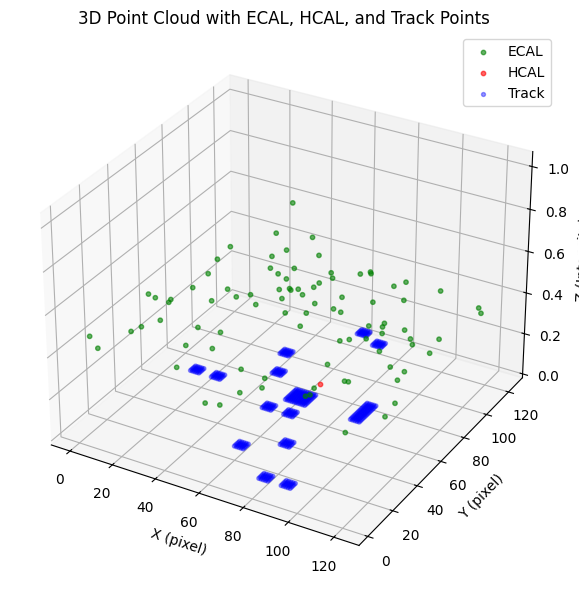

Processing Enhanced 3D Graphs: 30000it [00:33, 904.17it/s]


In [95]:
dataset = process_dataset(xdataset[:30000], ydataset[:30000], m0[:30000], pt[:30000 ])

In [ ]:

# Assuming `graph_dataset` is your list of Data objects
train_data, temp_data = train_test_split(dataset, test_size=0.4, random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

print(f"Train: {len(train_data)}, Validation: {len(val_data)}, Test: {len(test_data)}")


Train: 18000, Validation: 6000, Test: 6000


In [ ]:


batch_size = 32
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)


In [ ]:
class GNNBlock(nn.Module):
    def __init__(self, hidden_dim, input_dim=None):
        super(GNNBlock, self).__init__()
        input_dim = hidden_dim if input_dim is None else input_dim

        self.gat1 = GAT(input_dim, hidden_dim * 2, num_layers=2)
        self.nor1 = GraphNorm(hidden_dim * 2)
        self.gat2 = GAT(hidden_dim * 2, hidden_dim * 2, num_layers=2)

        self.sage1 = SAGEConv(input_dim, hidden_dim * 2)
        self.nor2 = GraphNorm(hidden_dim * 2)
        self.sage2 = SAGEConv(hidden_dim * 2, hidden_dim * 2)

        self.graphconv1 = GraphConv(input_dim, hidden_dim * 2)
        self.nor3 = GraphNorm(hidden_dim * 2)
        self.graphconv2 = GraphConv(hidden_dim * 2, hidden_dim * 2)

        self.gine1 = GINEConv(nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim * 2)
        ), edge_dim=1)
        self.nor4 = GraphNorm(hidden_dim * 2)
        self.gine2 = GINEConv(nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim * 2),
            nn.ReLU(),
            nn.Linear(hidden_dim * 2, hidden_dim * 2)
        ), edge_dim=1)

        self.norm1 = GraphNorm(hidden_dim * 8 + input_dim)
        self.norm2 = GraphNorm(hidden_dim * 2)

        self.final = GAT(hidden_dim * 8 + input_dim, hidden_dim * 2, num_layers=2)
        self.residual = GraphConv(input_dim, hidden_dim * 2)
        self.pool1 = SAGPooling(hidden_dim * 2, ratio=0.25)

    def forward(self, x, edge_index, batch, edge_weight=None):
        dense = x
        residual = self.residual(x, edge_index)  # Don't pass edge_weight to GraphConv

        # GAT Branch
        gat_out = F.silu(self.nor1(self.gat1(x, edge_index)))
        gat_out = self.gat2(gat_out, edge_index)

        # GraphSAGE Branch
        sage_out = F.silu(self.nor2(self.sage1(x, edge_index)))
        sage_out = self.sage2(sage_out, edge_index)

        # GINE Branch (reshape edge_weight)
        if edge_weight is not None:
            edge_attr = edge_weight.view(-1, 1)
        else:
            edge_attr = torch.ones((edge_index.size(1), 1), device=x.device)

        gine_out = F.silu(self.nor4(self.gine1(x, edge_index, edge_attr)))
        gine_out = self.gine2(gine_out, edge_index, edge_attr)

        # GraphConv Branch
        graphconv_out = F.silu(self.nor3(self.graphconv1(x, edge_index)))
        graphconv_out = self.graphconv2(graphconv_out, edge_index)

        # Concatenate and Pool
        x = F.silu(self.norm1(torch.cat([gat_out, sage_out, graphconv_out, gine_out, dense], dim=1)))
        x = F.silu(self.norm2(self.final(x, edge_index) + residual))

        x, edge_index, edge_weight, batch, _, _ = self.pool1(x, edge_index, edge_weight, batch)

        return x, edge_index, edge_weight, batch



class GNNModel(nn.Module):
    def __init__(self, input_dim=6, hidden_dim=24, output_dim=256):
        super(GNNModel, self).__init__()
        self.graph1 = GNNBlock(hidden_dim, input_dim)
        self.graph2 = GNNBlock(hidden_dim * 2)
        self.graph3 = GNNBlock(hidden_dim * 4)

        self.mlp = nn.Linear(hidden_dim * 8, output_dim)
        self.final_fc = nn.Linear(output_dim, 1)
        self.drop = nn.Dropout(0.0)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        edge_weight = data.edge_attr if hasattr(data, 'edge_attr') else None

        x, edge_index, edge_weight, batch = self.graph1(x, edge_index, batch, edge_weight)
        x, edge_index, edge_weight, batch = self.graph2(x, edge_index, batch, edge_weight)
        x, edge_index, edge_weight, batch = self.graph3(x, edge_index, batch, edge_weight)

        x = global_mean_pool(x, batch)
        x = F.silu(self.mlp(self.drop(x)))
        return torch.sigmoid(self.final_fc(self.drop(x)))


In [100]:
c=0
for xdata in train_data:
    if xdata.y == 1:
        c = c+1

In [101]:
len(train_data)

18000

In [102]:
def l2_regularization(model, weight_decay=1e-6, bias_decay=1e-8):
    weight_decay_loss = 0
    bias_decay_loss = 0
    for name, param in model.named_parameters():
        if 'weight' in name:
            weight_decay_loss += torch.norm(param, p=2)  # L2 norm for weights
        elif 'bias' in name:
            bias_decay_loss += torch.norm(param, p=1)  # L2 norm for biases
    return weight_decay * weight_decay_loss + bias_decay * bias_decay_loss


In [103]:
torch.autograd.set_detect_anomaly(True)

In [ ]:
device = torch.device("cpu" if torch.backends.mps.is_available() else "cpu")
model = GNNModel(input_dim=10, hidden_dim=32, output_dim=128).to(device)  # Output dim = 1 for binary classification

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5, verbose=True)  # Reduce LR if no improvement for 5 epochs
loss_fn = nn.BCELoss()

def train():
    model.train()
    for epoch in range(100):
        total_loss = 0
        correct = 0
        total = 0
        train_loader_tqdm = tqdm(train_loader, desc=f"Epoch {epoch+1}")

        for data in train_loader_tqdm:
            data = data.to(device)
            optimizer.zero_grad()
            
            output = model(data).squeeze()

            target = torch.tensor(data.y, dtype=torch.float, device=device)
            loss = loss_fn(output, target)


            regularization_loss = l2_regularization(model)
            loss = loss + regularization_loss  # Total loss = original loss + regularization
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            pred = (output > 0.5).float()
            correct += (pred == target).sum().item()
            total += len(target)

            train_loader_tqdm.set_postfix(loss=total_loss / (total + 1), acc=correct / (total + 1))

        val_loss = validate()  # Get validation loss for scheduler
        scheduler.step(val_loss)  # Adjust LR based on validation loss

        print(f"Epoch {epoch+1}, Loss: {total_loss / len(train_loader):.4f}, Accuracy: {correct / total:.4f}, LR: {optimizer.param_groups[0]['lr']}")


def validate():
    model.eval()
    correct = 0
    total = 0
    val_loss = 0

    with torch.no_grad():
        val_loader_tqdm = tqdm(val_loader, desc="Validation")
        for data in val_loader_tqdm:
            data = data.to(device)
            output = model(data).squeeze()

            target = torch.tensor(data.y, dtype=torch.float, device=device)

            loss = loss_fn(output, target)
            val_loss += loss.item()

            pred = (output > 0.5).float()
            correct += (pred == target).sum().item()
            total += len(target)

        print(f"Validation Loss: {val_loss / len(val_loader):.4f}, Accuracy: {correct / total:.4f}")
    return val_loss

train()


Validation: 100%|██████████| 188/188 [00:05<00:00, 36.30it/s]


Validation Loss: 0.6315, Accuracy: 0.6500
Epoch 1, Loss: 0.6715, Accuracy: 0.5738, LR: 0.0001


Validation: 100%|██████████| 188/188 [00:05<00:00, 34.79it/s]


Validation Loss: 0.6254, Accuracy: 0.6493
Epoch 2, Loss: 0.6350, Accuracy: 0.6466, LR: 0.0001


Validation: 100%|██████████| 188/188 [00:05<00:00, 36.40it/s]


...

Validation Loss: 0.5989, Accuracy: 0.6807
Epoch 59, Loss: 0.6023, Accuracy: 0.6819, LR: 1.0000000000000004e-08


Validation: 100%|██████████| 188/188 [00:05<00:00, 31.71it/s]


Validation Loss: 0.5989, Accuracy: 0.6807
Epoch 60, Loss: 0.6014, Accuracy: 0.6796, LR: 1.0000000000000004e-08


Epoch 61:  56%|█████▌    | 316/563 [17:59<14:03,  3.42s/it, acc=0.686, loss=0.0187]    


KeyboardInterrupt: 